## 1. Introduction to Plotly
1. Until now we did visualisations using Matplotlib. Seaborn and Pandas. All of them produce static image files.
2. Plotly is company based out in Canada famous for it's products like Plotly and Dash
3. Plotly creates interactive visualisations in the form of HTML files
4. `Drawback`- dan't work with a live data source
5. Dash is used to create live data based dashboards.

In [1]:
import numpy as np
import pandas as pd
import plotly.offline as pyo
import plotly.graph_objs as go

In [2]:
match = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')
ipl = delivery.merge(match, left_on='match_id',right_on='id')
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


# Scatter Plot

In [5]:
## scatter plot are drawn between two contineous variables
## Problem -> draw a scatter plot between Batsman Avg(x axis) and
## Batsman Strike_Rate(y axis) of the top 50 batsman in IPL (all time)

In [6]:
## avg and SR graph of top 50 batsman (in terms of run)
# fetching a new dataframe with top 50 batsman

top50 = ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(50).index.tolist()
new_ipl = ipl[ipl['batsman'].isin(top50)]
new_ipl

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150431,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,16,2,SR Watson,KL Rahul,BCJ Cutting,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150435,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,16,6,SR Watson,Sachin Baby,BCJ Cutting,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150436,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,17,1,SR Watson,Sachin Baby,Mustafizur Rahman,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150437,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,17,2,SR Watson,Sachin Baby,Mustafizur Rahman,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN


In [9]:
## Calculating SR
## SR = (number of runs scored)/(number of balls played)*100
runs = new_ipl.groupby('batsman')['batsman_runs'].sum()
balls = new_ipl.groupby('batsman')['batsman_runs'].count()

sr = ((runs)/(balls))*100

sr = sr.reset_index()
sr

,batsman,batsman_runs
0,AB de Villiers,145.129059
1,AC Gilchrist,133.054662
2,AJ Finch,126.299213
3,AM Rahane,117.486549
4,AT Rayudu,123.014257
5,BB McCullum,126.318203
6,BJ Hodge,121.422376
7,CH Gayle,144.194313
8,DA Miller,137.709251
9,DA Warner,138.318401


In [11]:
## Calculating Avg
## Avg = (total number of runs)/ (number of outs)

## calculating number of outs for top 50 batsman
out = ipl[ipl['player_dismissed'].isin(top50)]
nouts = out['player_dismissed'].value_counts()

avg = runs/nouts
avg = avg.reset_index()
avg.rename(columns={'index':'batsman',0:'avg'},inplace=True)

avg = avg.merge(sr,on='batsman')
avg.rename(columns={'batsman_runs':'strike_rate'},inplace=True)
avg.head()

,batsman,avg,strike_rate
0,AB de Villiers,38.307692,145.129059
1,AC Gilchrist,27.223684,133.054662
2,AJ Finch,27.186441,126.299213
3,AM Rahane,33.593407,117.486549
4,AT Rayudu,27.146067,123.014257


In [14]:
## plot scatter plot here
trace = go.Scatter(x=avg['avg'], y=avg['strike_rate'], mode='markers',
                  text=avg['batsman'],
                  marker={'color':'#00a65a','size':16})

data = [trace]

layout = go.Layout(title='Batsman Avg vs SR',
                  xaxis={'title':'Batsman Average'},
                  yaxis={'title':'Batsman SR'})

fig = go.Figure(data=data, layout=layout)

pyo.plot(fig,filename='myfile.html')

'myfile.html'

# Line Chart
> used for time series data

In [16]:
## Year by year batsman performance
single = ipl[ipl['batsman']=='V Kohli']
performance = single.groupby('season')['batsman_runs'].sum().reset_index()
performance

single1 = ipl[ipl['batsman']=='MS Dhoni']
performance1 = single1.groupby('season')['batsman_runs'].sum().reset_index()
performance1

,season,batsman_runs
0,2008,414
1,2009,332
2,2010,287
3,2011,392
4,2012,357
5,2013,461
6,2014,371
7,2015,372
8,2016,284
9,2017,290


In [17]:
trace0 = go.Scatter(x=performance['season'],
               y=performance['batsman_runs'],
               mode='lines+markers',
               marker={'color':'#00a65a'},
                name='Virat Kohli')


trace1 = go.Scatter(x=performance1['season'],
               y=performance1['batsman_runs'],
               mode='lines+markers',
               marker={'color':'red'},
                name="MS Dhoni")

data = [trace0,trace1]
layout = go.Layout(title="Batsman Year By Year Performance",
                  xaxis={'title':'Seasons'},
                  yaxis={'title':'Runs'})

fig = go.Figure(data=data, layout=layout)

pyo.plot(fig)

'temp-plot.html'

In [18]:
## Multiple Line charts
def batsman_comp(*name):
    data = []
    for i in name:
        single=ipl[ipl['batsman']==i]
        performance = single.groupby('season')['batsman_runs'].sum().reset_index()

        trace = go.Scatter(x=performance['season'],y=performance['batsman_runs'],
                          mode='lines+markers',name=i)
        data.append(trace)

    layout = go.Layout(title='Batsman Record Comparator',
                      xaxis={'title':'Season'},
                      yaxis={'title':'Runs'})

    fig = go.Figure(data=data,layout=layout)
    pyo.plot(fig,filename='year_by_by.html')

In [19]:
batsman_comp('V Kohli','MS Dhoni','RG Sharma','DA Warner')

# Bar Plot
* > used to show ralation between one categorical and one numerical data

In [26]:
top10 = ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10).index.tolist()
top10_df = ipl[ipl['batsman'].isin(top10)]

In [28]:
top10_score = top10_df.groupby('batsman')['batsman_runs'].sum().reset_index()

In [30]:
top10_score

,batsman,batsman_runs
0,AB de Villiers,3486
1,CH Gayle,3651
2,DA Warner,4014
3,G Gambhir,4132
4,MS Dhoni,3560
5,RG Sharma,4207
6,RV Uthappa,3778
7,S Dhawan,3561
8,SK Raina,4548
9,V Kohli,4423


In [39]:
## plot bar graph
trace = go.Bar(x=top10_score['batsman'],y=top10_score['batsman_runs'],
              marker={'color':'green'})

data = [trace]
layout = go.Layout(title='Top 10 Batsman Score Record',
                  xaxis={'title':'Batsman_Name',},
                  yaxis={'title':'Batsman_Score'})

fig = go.Figure(data=data,layout=layout)

pyo.plot(fig)

'temp-plot.html'

### There are 3 types of Bar Graphs
* 1. Nested Bar Graph
  2. Stacked Bar Graph
  3. Overlayed Bar Graph

In [35]:
iw = top10_df.groupby(['batsman','inning'])['batsman_runs'].sum().reset_index()
mask1 = iw['inning']==1
mask2 = iw['inning']==2
one = iw[mask1]
two = iw[mask2]

one.rename(columns={'batsman_runs':'1st Innings'},inplace=True)
two.rename(columns={'batsman_runs':'2nd Innings'},inplace=True)

final = one.merge(two,on='batsman')[['batsman','1st Innings','2nd Innings']].copy()

C:\Users\vikas\AppData\Local\Temp\ipykernel_18704\901793201.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\vikas\AppData\Local\Temp\ipykernel_18704\901793201.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [37]:
trace1 = go.Bar(x=final['batsman'],y=final['1st Innings'],name='1st innings',
               marker={'color':'green'})

trace2 = go.Bar(x=final['batsman'],y=final['2nd Innings'],name='2nd innings',
               marker={'color':'red'})

data = [trace1,trace2]
layout = go.Layout(title='Innings Wise Score',
                  xaxis={'title':'Batsman'},
                  yaxis={'title':'overlay'})

fig = go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

# Bubble Plot
* > an extension of scatter plot with some additional information

In [126]:
new_ipl = new_ipl[new_ipl['batsman_runs']==6]
six = new_ipl[new_ipl['batsman'].isin(avg['batsman'].tolist())].groupby('batsman')['batsman_runs'].count().reset_index()

In [134]:
df = avg.merge(six,on='batsman')
df.rename(columns={'batsman_runs':'no_of_six'},inplace=True)
df

,batsman,avg,strike_rate,no_of_six
0,AB de Villiers,38.307692,145.129059,158
1,AC Gilchrist,27.223684,133.054662,92
2,AJ Finch,27.186441,126.299213,59
3,AM Rahane,33.593407,117.486549,60
4,AT Rayudu,27.146067,123.014257,79
5,BB McCullum,28.112245,126.318203,124
6,BJ Hodge,33.333333,121.422376,43
7,CH Gayle,41.022472,144.194313,266
8,DA Miller,34.733333,137.709251,78
9,DA Warner,40.140000,138.318401,160


In [144]:
trace = go.Scatter(x=df['avg'],y=df['strike_rate'],
                  mode='markers',
                  marker={'size':df['no_of_six']},hovertext=df['batsman'])
data = [trace]
layout=go.Layout(title='Bubble Chart',
                xaxis={'title':'Average'},
                yaxis={'title':'SR'})
fig = go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

# Box Plot

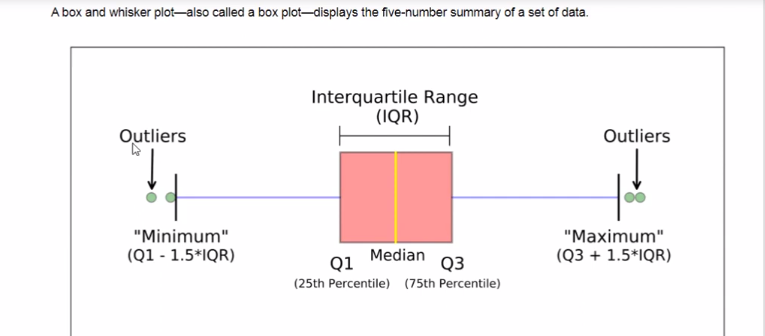

In [147]:
match_agg = delivery.groupby('match_id')['total_runs'].sum().reset_index()
season_wise = match_agg.merge(match,left_on='match_id',right_on='id')[['match_id','total_runs','season']]
season_wise

,match_id,total_runs,season
0,1,379,2017
1,2,371,2017
2,3,367,2017
3,4,327,2017
4,5,299,2017
...,...,...,...
631,632,277,2016
632,633,317,2016
633,634,302,2016
634,635,325,2016


In [151]:
trace1 = go.Box(x=season_wise[season_wise['season']==2017]['total_runs'],
               marker={'color':'green'})

trace2 = go.Box(x=season_wise[season_wise['season']==2008]['total_runs'],
               marker={'color':'red'})

data = [trace1,trace2]
layout = go.Layout(title='Total Score Analysis',
                  xaxis={'title':'total score'})

fig = go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

# DistPlot
> combination of three plot
* 1. histogram
  2. rug plot
  3. KDE

In [154]:
## Plot Distplot
import plotly.figure_factory as ff

In [158]:
hist_data = [avg['avg'],avg['strike_rate']]

group_label = ['Average','Strike_Rate']
fig = ff.create_distplot(hist_data,group_label,bin_size=[10,20])

pyo.plot(fig)

'temp-plot.html'

# Histogram
> A histogram is a plot that lets you discover and show the underlying frequency distribution (shape) of the set of continuous data

In [161]:
x = delivery.groupby('batsman')['batsman_runs'].count()>150
x = x[x].index.tolist()

new = delivery[delivery['batsman'].isin(x)]

runs = new.groupby('batsman')['batsman_runs'].sum()
balls = new.groupby('batsman')['batsman_runs'].count()

sr = (runs/balls)*100
sr = sr.reset_index()
sr

,batsman,batsman_runs
0,A Ashish Reddy,142.857143
1,A Mishra,89.756098
2,A Symonds,124.711908
3,AA Jhunjhunwala,99.541284
4,AB Agarkar,111.875000
...,...,...
169,Y Nagar,105.166052
170,Y Venugopal Rao,113.872832
171,YK Pathan,138.860326
172,YV Takawale,104.918033


In [169]:
## plot histogram
trace = go.Histogram(x=sr['batsman_runs'],name='strike_rate_variations',xbins={'size':2,'start':50,'end':100})
data = [trace]
layout = go.Layout(title='Strike Rate Analysis',
                  xaxis={'title':'Strike Rate Runs'})
fig = go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

# Heatmaps

In [172]:
six = delivery[delivery['batsman_runs']==6]
six = six.groupby(['batting_team','over'])['batsman_runs'].count().reset_index()
six

,batting_team,over,batsman_runs
0,Chennai Super Kings,1,9
1,Chennai Super Kings,2,21
2,Chennai Super Kings,3,49
3,Chennai Super Kings,4,45
4,Chennai Super Kings,5,53
...,...,...,...
290,Sunrisers Hyderabad,16,31
291,Sunrisers Hyderabad,17,25
292,Sunrisers Hyderabad,18,49
293,Sunrisers Hyderabad,19,58


In [176]:
dots = delivery[delivery['batsman_runs']==0]
dots = dots.groupby(['batting_team','over'])['batsman_runs'].count().reset_index()
dots

,batting_team,over,batsman_runs
0,Chennai Super Kings,1,642
1,Chennai Super Kings,2,583
2,Chennai Super Kings,3,520
3,Chennai Super Kings,4,516
4,Chennai Super Kings,5,464
...,...,...,...
295,Sunrisers Hyderabad,16,202
296,Sunrisers Hyderabad,17,216
297,Sunrisers Hyderabad,18,171
298,Sunrisers Hyderabad,19,181


In [174]:
## plot heatmap
trace = go.Heatmap(x=six['batting_team'],y=six['over'],z=six['batsman_runs'])
data = [trace]

layout = go.Layout(title='Sixes Heatmap')
fig = go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

In [178]:
## side by side heatmap
from plotly import tools

In [180]:
trace1 = go.Heatmap(x=six['batting_team'],y=six['over'],z=six['batsman_runs'].values.tolist())
trace2 = go.Heatmap(x=dots['batting_team'],y=dots['over'],z=dots['batsman_runs'].values.tolist())

fig = tools.make_subplots(rows=1,cols=2,subplot_titles=["6's","0's"], shared_yaxes=True)

fig.append_trace(trace1,1,1)
fig.append_trace(trace2,1,2)

pyo.plot(fig)

D:\Conda\Lib\site-packages\plotly\tools.py:455: DeprecationWarning:

plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead



'temp-plot.html'